## 1. Imports y descarga completa de archivos

In [5]:
import boto3, os, threading

BUCKET   = "xideralaws-curso-christian-1"
S3_KEY   = "raw/year=2023/month=01/fhvhv_tripdata_2023-01.parquet"
LOCAL_F  = "/tmp/fhvhv_2023-01.parquet"  # /tmp tiene más espacio

def download():
    s3 = boto3.client("s3")
    size = s3.head_object(Bucket=BUCKET, Key=S3_KEY)["ContentLength"]
    downloaded = [0]
    def progress(chunk):
        downloaded[0] += chunk
        pct = downloaded[0] / size * 100
        print(f"\r{pct:.1f}%", end="", flush=True)
    s3.download_file(BUCKET, S3_KEY, LOCAL_F,
                     Callback=progress)
    print("\n✓ Descarga completa")

if not os.path.exists(LOCAL_F):
    t = threading.Thread(target=download)
    t.start()
else:
    print("✓ Ya existe en /tmp")

100.0%
✓ Descarga completa


## 2. Leer solo las columnas necesarias

In [6]:
import pandas as pd, pyarrow.parquet as pq

COLS = ["hvfhs_license_num", "pickup_datetime", "PULocationID",
        "trip_miles", "base_passenger_fare", "tips", "shared_request_flag"]

df = pq.read_table(LOCAL_F, columns=COLS).to_pandas()
print(f"✓ Filas: {len(df):,}")
print(df.dtypes)

✓ Filas: 18,479,031
hvfhs_license_num              object
pickup_datetime        datetime64[us]
PULocationID                    int64
trip_miles                    float64
base_passenger_fare           float64
tips                          float64
shared_request_flag            object
dtype: object


## 3. Muestra de 50k filas para gráficos

In [7]:
df_sample = df.sample(n=50_000, random_state=42)
print(f"✓ Muestra: {len(df_sample):,} filas")

✓ Muestra: 50,000 filas


## 4. Uber vs Lyft

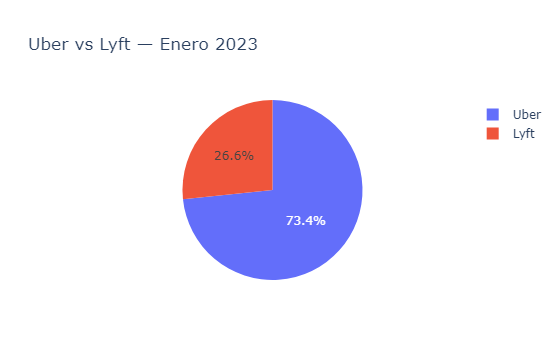

In [8]:
import plotly.express as px
df_sample["platform"] = df_sample["hvfhs_license_num"].map(
    {"HV0003": "Uber", "HV0005": "Lyft"}
)
px.pie(df_sample, names="platform",
       title="Uber vs Lyft — Enero 2023").show()

## 5. Distribución de tarifas

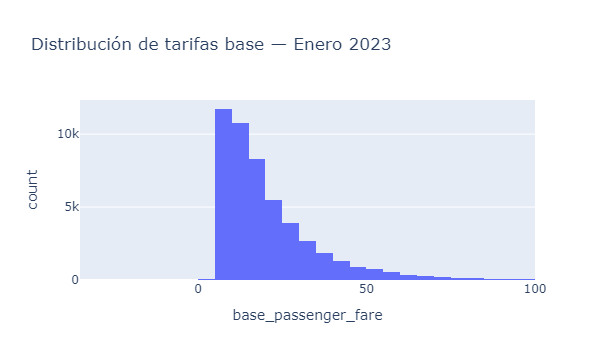

In [10]:
px.histogram(
    df_sample[df_sample["base_passenger_fare"] < 100],
    x="base_passenger_fare", nbins=40,
    title="Distribución de tarifas base — Enero 2023"
).show()

## 6. Demanda por hora

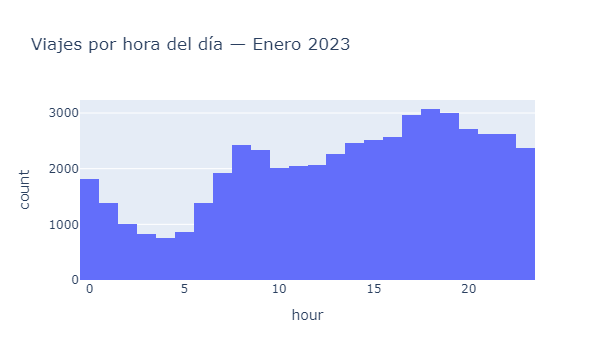

In [12]:
df_sample["hour"] = df_sample["pickup_datetime"].dt.hour
px.histogram(df_sample, x="hour",
             title="Viajes por hora del día — Enero 2023").show()

## 7. Join con taxi zones

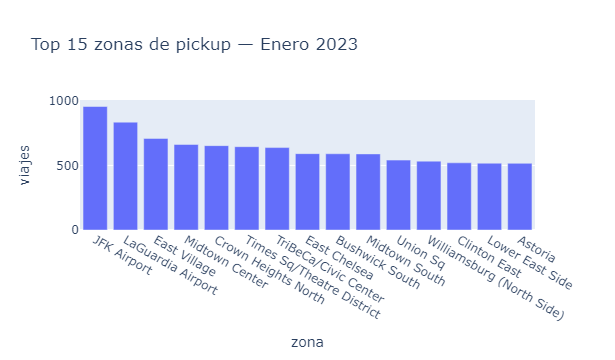

In [14]:
import boto3, io
s3    = boto3.client("s3")
zones = pd.read_csv(io.BytesIO(
    s3.get_object(Bucket="xideralaws-curso-christian-1",
                  Key="reference/taxi_zone_lookup.csv")["Body"].read()
))
df_z = df_sample.merge(
    zones.rename(columns={"LocationID": "PULocationID", "Zone": "pickup_zone"}),
    on="PULocationID", how="left"
)
top = df_z["pickup_zone"].value_counts().head(15).reset_index()
top.columns = ["zona", "viajes"]
px.bar(top, x="zona", y="viajes",
       title="Top 15 zonas de pickup — Enero 2023").show()